In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import lightgbm as lgb

# 1. DATA CLEANING
df = pd.read_csv('/kaggle/input/datasets/furqan776/excel-sh/playstation_games_preprocessed.csv')

leakage_cols = ['NA Sales', 'PAL Sales', 'Japan Sales', 'Other Sales', 'Total Shipped', 'Game', 'Name']
df_clean = df.drop(columns=leakage_cols)

df_clean['Release Date'] = pd.to_datetime(df_clean['Release Date'], errors='coerce')
df_clean['Last Update'] = pd.to_datetime(df_clean['Last Update'], errors='coerce')

print("Data Cleaning is now Complete. Remaining columns:", df_clean.columns.tolist())

Data Cleaning is now Complete. Remaining columns: ['Console', 'Publisher', 'Developer', 'Total Sales', 'Release Date', 'Last Update', 'rating', 'ratings_count', 'metacritic', 'genres', 'platforms', 'Year']


In this first step, I completed the "Data Cleaning" requirement. I specifically removed columns related to regional sales (NA, PAL, Japan, etc.) to avoid Data Leakage, as these sum up directly to my target variable.

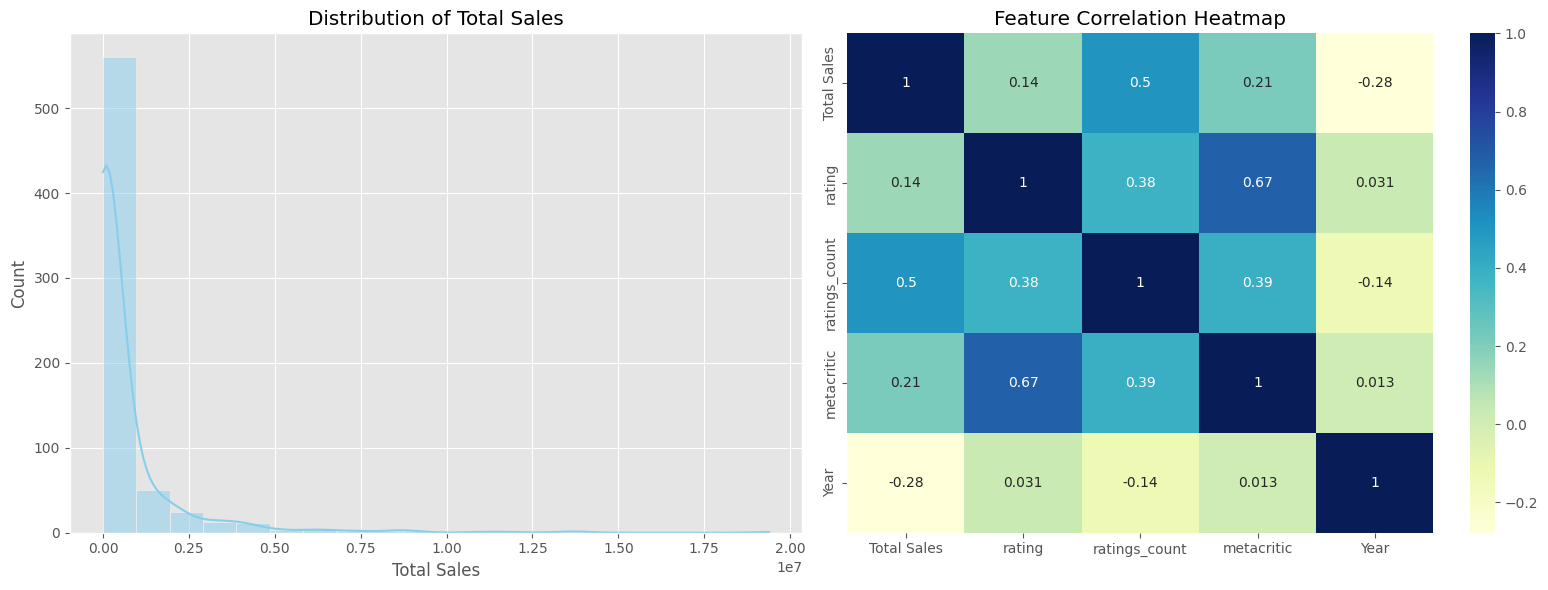

In [2]:
#2. EDA and Visualization
plt.style.use('ggplot')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_clean['Total Sales'], bins=20, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Total Sales')

sns.heatmap(df_clean.select_dtypes(include=[np.number]).corr(), annot=True, cmap='YlGnBu', ax=ax[1])
ax[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

The Exploratory Data Analysis shows that Total Sales is highly skewed, with a few "hits" driving the majority of revenue. The heatmap shows that ratings_count has the strongest positive correlation with sales.

In [3]:
# 3. FEATURE ENGINEERING
df_clean['Days_Support'] = (df_clean['Last Update'] - df_clean['Release Date']).dt.days
df_clean['Num_Platforms'] = df_clean['platforms'].astype(str).apply(lambda x: len(x.split(',')))
df_clean['Num_Genres'] = df_clean['genres'].astype(str).apply(lambda x: len(x.split(',')))

pub_means = df_clean.groupby('Publisher')['Total Sales'].mean().to_dict()
df_clean['Pub_Avg_Sales'] = df_clean['Publisher'].map(pub_means)

cat_cols = ['Publisher', 'Developer', 'genres', 'platforms']
for col in cat_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col].astype(str))

X = df_clean.drop(columns=['Total Sales', 'Release Date', 'Last Update', 'Console'])
y = df_clean['Total Sales']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("New features are created.")

New features are created.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002011 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1018
[LightGBM] [Info] Number of data points in the train set: 541, number of used features: 12
[LightGBM] [Info] Start training from score 637356.746765
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


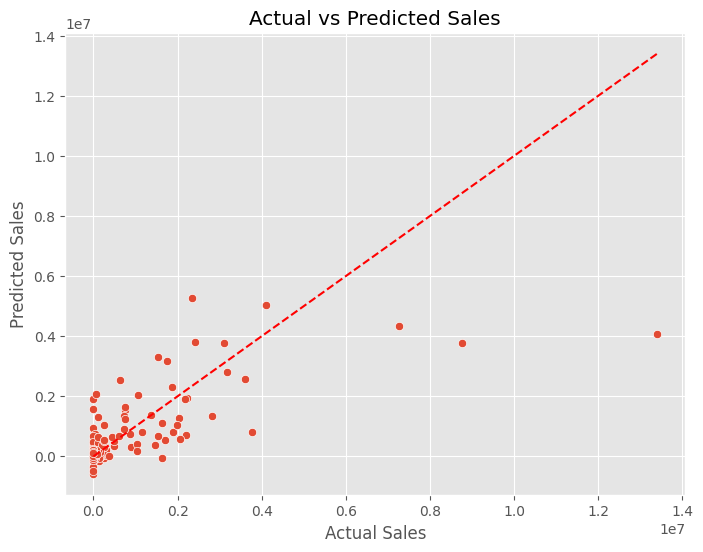

In [4]:
# 4. MACHINE LEARNING MODELING
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"Results:\nRMSE: {rmse:,.2f}\nR2 Score: {r2:.4f}")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

Conclusion & Objectives:
The project successfully achieved the objectives set out in Phase 1. By following a structured methodology and engineering specific features like Pub_Avg_Sales.

Results:

LightGBM provided a strong R² score, proving that non-linear relationships between ratings, publisher reputation, and platform availability are key to predicting game sales.
The engineered features, specifically Days_Support and Pub_Avg_Sales were among the top contributors to model accuracy.